In [1]:
import numpy as np
import time
import mpmath as mp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
mp.mp.dps = 50

In [2]:
def iszero(a, eps=1e-10):
    if np.abs(a) < eps:
        return True
    return False

def get_m1_k(a, k, n):
    if iszero(a):
        return k/(n+1)
    b = (0.5*a-1)**2
    return float(0.5 - 1/a + np.sqrt(b) / a * mp.hyp2f1(-0.5, k, n+1, -2*a/b))

def get_m2(a):
    return (a+4)/12

def expected_wasserstein_loss_affine(a1, a2, n, m1_a1=None, m1_a2=None):
    if m1_a1 is None:
        m1_a1 = np.array([get_m1_k(a1, k+1, n) for k in range(n)])
    if m1_a2 is None:
        m1_a2 = np.array([get_m1_k(a2, k+1, n) for k in range(n)])
    dist = -2*np.mean(m1_a1*m1_a2) + get_m2(a1) + get_m2(a2)
    return dist

In [3]:
def numerical_sol_expected_loss(a1: float,
                         n:  int,
                        m1_a1 = None,
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        return float(expected_wasserstein_loss_affine(a1, a2, n, m1_a1=m1_a1))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2, 2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [4]:
def numerical_sol_expected_loss_debias(a1: float,
                         n:  int,
                        m1_a1 = None,
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        m1_a2 = np.array([get_m1_k(a2, k+1, n) for k in range(n)])
        return float(expected_wasserstein_loss_affine(a1, a2, n, m1_a1=m1_a1, m1_a2=m1_a2) - 0.5*expected_wasserstein_loss_affine(a2, a2, n, m1_a1=m1_a2, m1_a2=m1_a2))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2, 2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

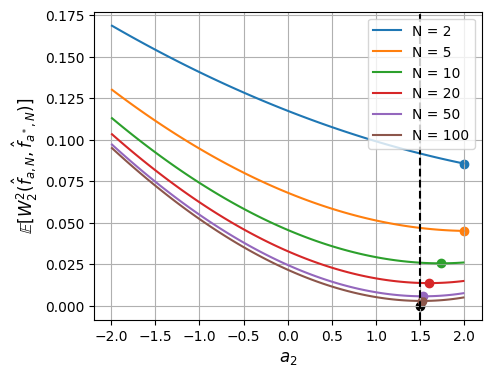

In [17]:
a1=1.5
a2s = np.linspace(-1.99, 1.99, 101)

m1_a1_set = {}
m1_a2s_set = {}
Nset = [2, 5, 10, 20, 50, 100]
for N in Nset:
    m1_a1_set[str(N)] = np.array([get_m1_k(a1, k+1, N) for k in range(N)])
    m1_a2s_set[str(N)] = [np.array([get_m1_k(a2, k+1, N) for k in range(N)]) for a2 in a2s]

expected_loss_set = {}
expected_loss_diag_set = {}
expected_loss_minimizer_set = {}
expected_loss_debias_minimizer_set = {}
for N in Nset:
    expected_loss_set[str(N)] = np.array([expected_wasserstein_loss_affine(a1, a2, N, m1_a1=m1_a1_set[str(N)]) for a2 in a2s])
    a_hat, _ = numerical_sol_expected_loss(a1, N, m1_a1=m1_a1_set[str(N)])
    expected_loss_minimizer_set[str(N)] = a_hat
    
    expected_loss_diag_set[str(N)] = np.array([expected_wasserstein_loss_affine(a2, a2, N, 
                                            m1_a1=m1_a2s_set[str(N)][j], m1_a2=m1_a2s_set[str(N)][j]) for j, a2 in enumerate(a2s)])
    a_hat, _ = numerical_sol_expected_loss_debias(a1, N, m1_a1=m1_a1_set[str(N)])
    expected_loss_debias_minimizer_set[str(N)] = a_hat

plt.figure(figsize=(5,4))
plt.scatter(a1, 0, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(a2s, expected_loss_set[str(N)], label=f'N = {N}')
    # plt.plot(a2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_a = expected_loss_minimizer_set[str(N)]
    plt.scatter(temp_a, expected_wasserstein_loss_affine(a1, temp_a, N, m1_a1=m1_a1_set[str(N)]), marker='o')
plt.axvline([a1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$a_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{a, N}, \hat{f}_{a^*, N})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)

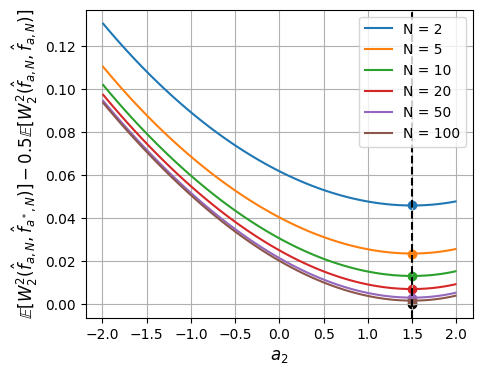

In [18]:
plt.figure(figsize=(5,4))
plt.scatter(a1, 0, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(a2s, expected_loss_set[str(N)] - 0.5*expected_loss_diag_set[str(N)], label=f'N = {N}')
    # plt.plot(a2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_a = expected_loss_debias_minimizer_set[str(N)]
    plt.scatter(temp_a, expected_wasserstein_loss_affine(a1, temp_a, N, m1_a1=m1_a1_set[str(N)]) \
                - 0.5*expected_wasserstein_loss_affine(temp_a, temp_a, N), marker='o')
plt.axvline([a1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$a_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{a, N}, \hat{f}_{a^*, N})] - 0.5\mathbb{E}[W_2^2(\hat{f}_{a, N}, \hat{f}_{a, N})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [5]:
N = 10
a1s = np.linspace(-1.99, 1.99, 201)
a2s = a1s
m1_a1s = [np.array([get_m1_k(a1, k+1, N) for k in range(N)]) for a1 in a1s]
m1_a2s = m1_a1s

In [6]:
expected_was = np.empty((len(a2s), len(a1s)))
for i, a1 in enumerate(a1s):
    for j, a2 in enumerate(a2s):
        expected_was[j,i] = expected_wasserstein_loss_affine(a1, a2, N, m1_a1=m1_a1s[i], m1_a2=m1_a2s[j])

In [7]:
np.max(expected_was)

0.13579856136782925

In [8]:
a1s_ = np.linspace(-1.99, 1.99, 51)
m1_a1s_ = [np.array([get_m1_k(a1, k+1, N) for k in range(N)]) for a1 in a1s_]
opt_a2s = np.empty(len(a1s_))
opt_vals = np.empty(len(a1s_))
for i, a1 in enumerate(a1s_):
    opt_a2s[i], opt_vals[i] = numerical_sol_expected_loss(a1, N, m1_a1=m1_a1s_[i])

In [20]:
a1s = np.linspace(-1.99, 1.99, 201)
a2s = a1s

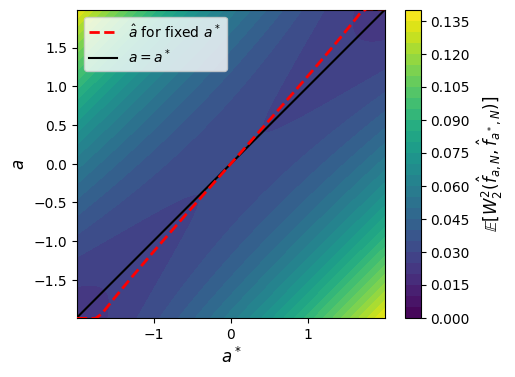

In [21]:
plt.figure(figsize=(5,4))
clev = np.linspace(0,0.14,29)
h = plt.contourf(a1s, a2s, expected_was, clev)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbb{E}[W_2^2(\hat{f}_{a, N}, \hat{f}_{a^*, N})]$', fontsize=12)
#plt.plot(w_list_np[:,0], w_list_np[:,1], c='orange', marker='o')

# cs = np.linspace(0.1, 2.0, 20)
# for c in cs:
#     temp_lambda2 = lambda1s/(2*lambda1s*c - 1)
#     plt.plot(1/lambda1s[temp_lambda2>lambda2s.min()], 1/temp_lambda2[temp_lambda2>lambda2s.min()], 'k--')
#plt.scatter(w_opt[0], w_opt[1], c='r', s=200, marker='*', zorder=10)
plt.axis('scaled')
plt.xlabel(r'$a^*$', fontsize=12)
plt.ylabel(r'$a$', fontsize=12)
plt.xlim([(a1s).min(), (a1s).max()])
plt.ylim([(a2s).min(), (a2s).max()])
plt.plot(a1s_, opt_a2s, 'r--', linewidth=2, label=r'$\hat{a}$ for fixed $a^*$', zorder=10)
plt.plot(a1s, a2s, 'k', label=r'$a = a^*$', zorder=1)
# plt.plot(a1s, a2s, 'y--')
plt.legend()
# plt.savefig(f'./fig_expected_loss_affine.pdf', format='pdf', bbox_inches="tight", dpi=300)
plt.show()

### debias

In [10]:
expected_was_diag = np.empty((len(a2s), len(a1s)))
for j, a2 in enumerate(a2s):
    temp = expected_wasserstein_loss_affine(a2, a2, N, m1_a1=m1_a2s[j], m1_a2=m1_a2s[j])
    for i, a1 in enumerate(a1s):
        expected_was_diag[j,i] = temp

In [11]:
a1s_ = np.linspace(-1.99, 1.99, 51)
m1_a1s_ = [np.array([get_m1_k(a1, k+1, N) for k in range(N)]) for a1 in a1s_]
opt_a2s_debias = np.empty(len(a1s_))
opt_vals_debias = np.empty(len(a1s_))
for i, a1 in enumerate(a1s_):
    opt_a2s_debias[i], opt_vals_debias[i] = numerical_sol_expected_loss_debias(a1, N, m1_a1=m1_a1s_[i])

In [22]:
a1s = np.linspace(-1.99, 1.99, 201)
a2s = a1s

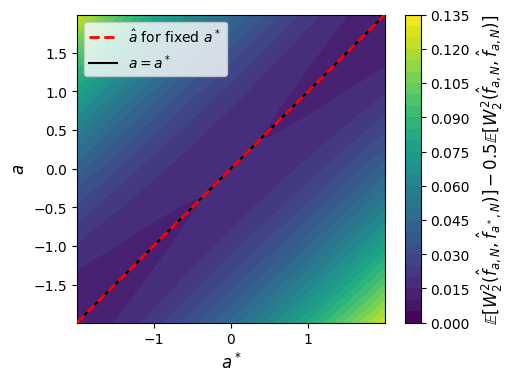

In [24]:
plt.figure(figsize=(5,4))
clev = np.linspace(0,0.135,28)
h = plt.contourf(a1s, a2s, expected_was - 0.5*expected_was_diag, clev)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbb{E}[W_2^2(\hat{f}_{a, N}, \hat{f}_{a^*, N})] - 0.5\mathbb{E}[W_2^2(\hat{f}_{a, N}, \hat{f}_{a, N})]$', fontsize=12)
#plt.plot(w_list_np[:,0], w_list_np[:,1], c='orange', marker='o')

# cs = np.linspace(0.1, 2.0, 20)
# for c in cs:
#     temp_lambda2 = lambda1s/(2*lambda1s*c - 1)
#     plt.plot(1/lambda1s[temp_lambda2>lambda2s.min()], 1/temp_lambda2[temp_lambda2>lambda2s.min()], 'k--')
#plt.scatter(w_opt[0], w_opt[1], c='r', s=200, marker='*', zorder=10)
plt.axis('scaled')
plt.xlabel(r'$a^*$', fontsize=12)
plt.ylabel(r'$a$', fontsize=12)
plt.xlim([(a1s).min(), (a1s).max()])
plt.ylim([(a2s).min(), (a2s).max()])
plt.plot(a1s_, opt_a2s_debias, 'r--', linewidth=2, label=r'$\hat{a}$ for fixed $a^*$', zorder=10)
plt.plot(a1s, a2s, 'k', label=r'$a = a^*$', zorder=1)
# plt.plot(a1s, a2s, 'y--')
plt.legend()
# plt.savefig(f'./fig_expected_loss_affine_modified.pdf', format='pdf', bbox_inches="tight", dpi=300)
plt.show()

In [13]:
Ns = [2, 5, 10, 20, 50, 100]
a1s = np.linspace(-1.99, 1.99, 201)

expected_was_diagonal = np.empty((len(Ns), len(a1s)))
for j, N in enumerate(Ns):
    m1_a1s_ = [np.array([get_m1_k(a1, k+1, N) for k in range(N)]) for a1 in a1s]
    for i, a1 in enumerate(a1s):
        expected_was_diagonal[j,i] = expected_wasserstein_loss_affine(a1, a1, N, m1_a1=m1_a1s_[i], m1_a2=m1_a1s_[i])

Text(0, 0.5, '$\\mathbb{E}[W_2^2(\\hat{f}_{a,N}, \\hat{f}_{a,N})]$')

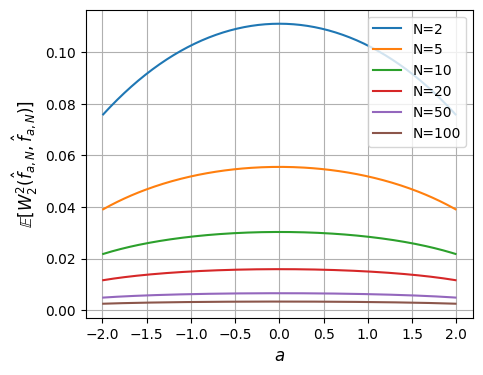

In [14]:
plt.figure(figsize=(5,4))
for j, N in enumerate(Ns):
    plt.plot(a1s, expected_was_diagonal[j], label=f'N={N}')
plt.grid()
plt.legend()
plt.xlabel(r'$a$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{a,N}, \hat{f}_{a,N})]$', fontsize=12)
# plt.savefig(f'./fig_expected_loss_affine_diagonal.pdf', format='pdf', bbox_inches="tight", dpi=300)